# Task 1: Exploratory Data Analysis (EDA):

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [2]:
df = pd.read_csv("wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [4]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


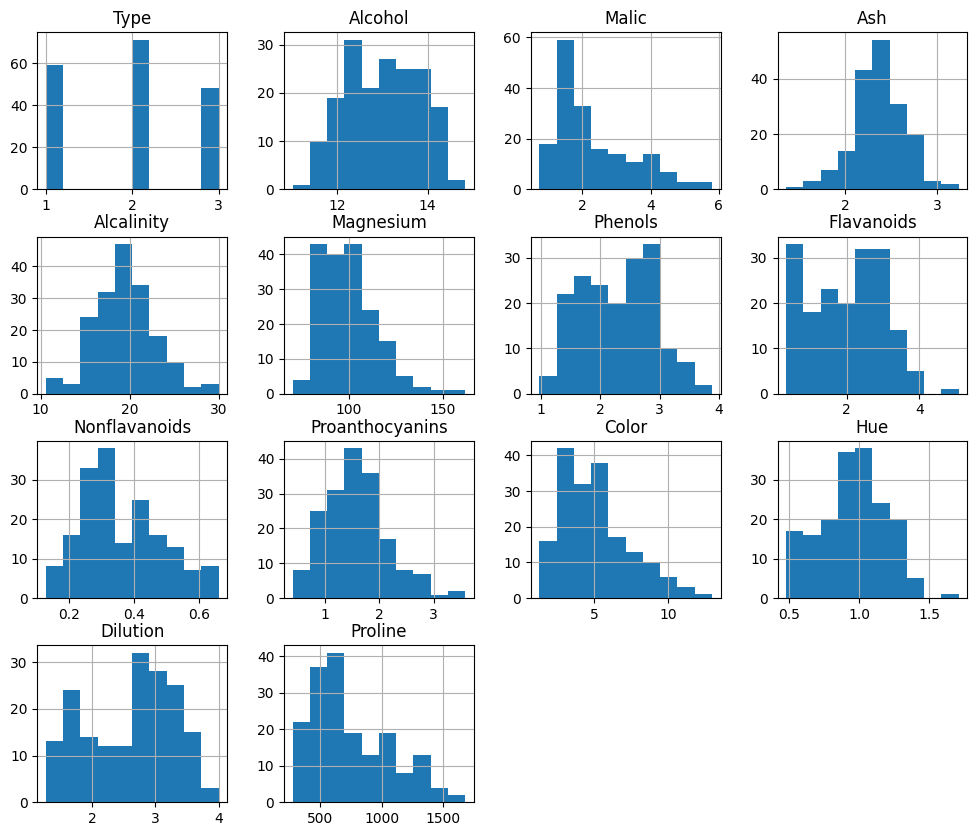

In [6]:
df.hist(figsize=(12,10))
plt.show()

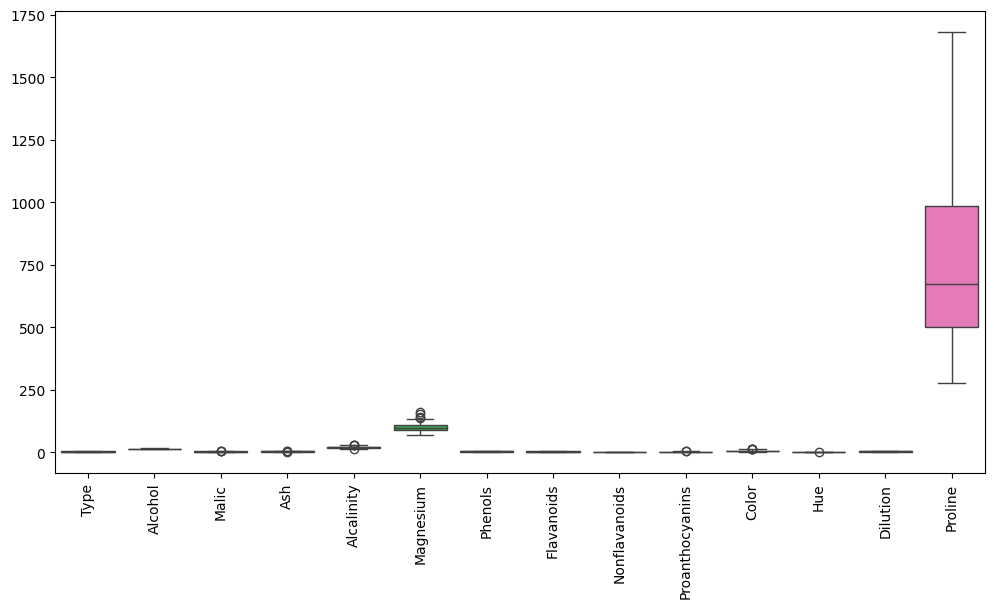

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

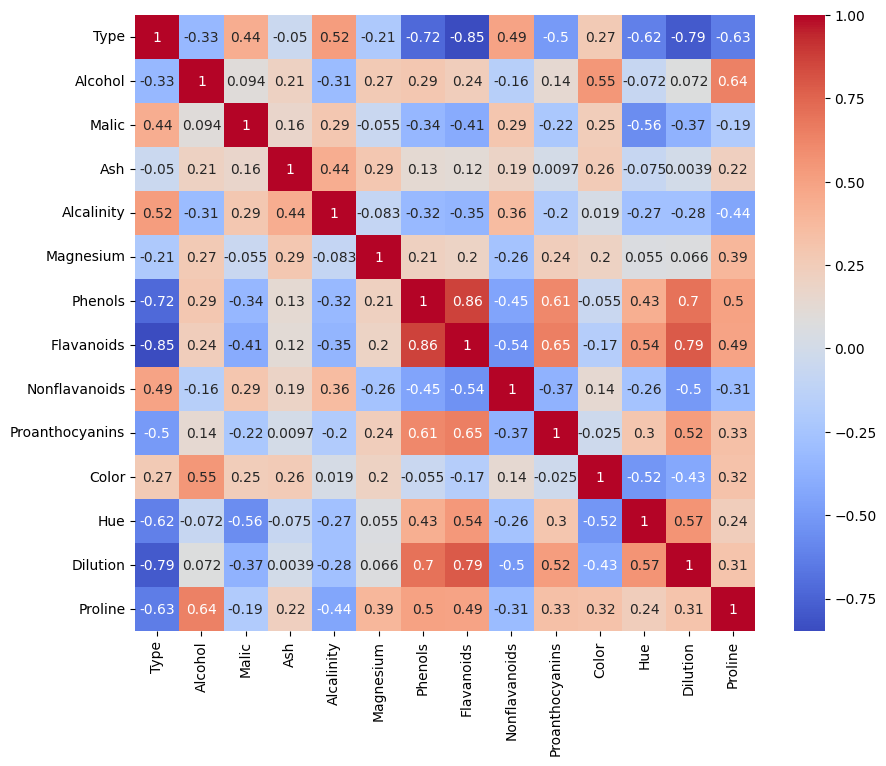

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Task 2: Dimensionality Reduction with PCA:

In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [10]:
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

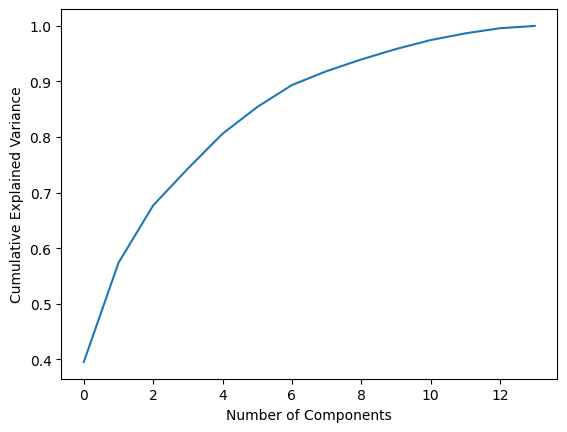

In [11]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [12]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=['PC1','PC2'])
pca_df.head()

,PC1,PC2
0,-3.522934,1.453098
1,-2.528858,-0.330019
2,-2.785029,1.036936
3,-3.922588,2.768210
4,-1.407511,0.867773


# Task 3: Clustering with Original Data:

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [14]:
df['Cluster'] = clusters

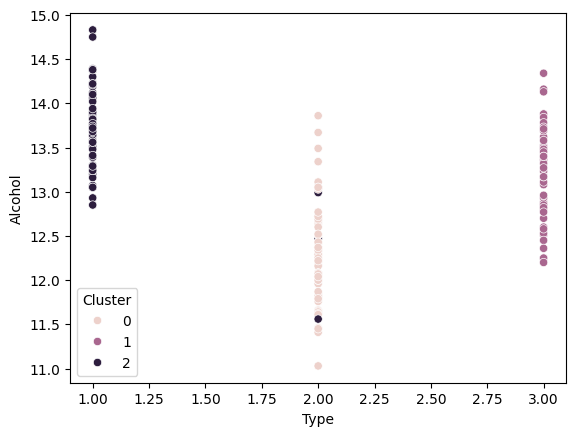

In [15]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1], hue=df['Cluster'])
plt.show()

In [16]:
sil_score = silhouette_score(scaled_data, clusters)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.30648398324833453


In [17]:
db_score = davies_bouldin_score(scaled_data, clusters)
print("Davies Bouldin Score:", db_score)

Davies Bouldin Score: 1.315707552261773


# Task 4: Clustering with PCA Data:

In [18]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
pca_clusters = kmeans_pca.fit_predict(pca_df)

In [19]:
pca_df['Cluster'] = pca_clusters

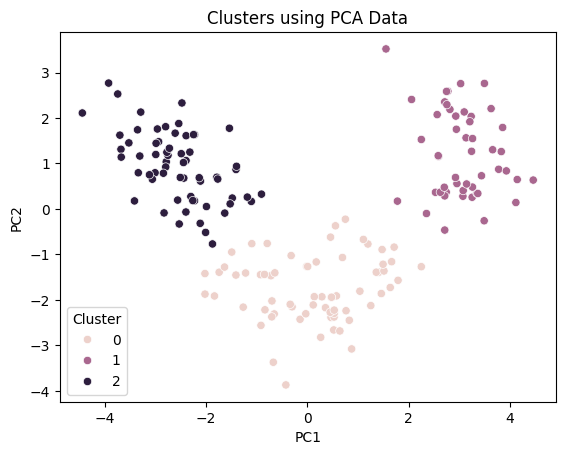

In [20]:
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster')
plt.title("Clusters using PCA Data")
plt.show()

In [21]:
sil_score_pca = silhouette_score(pca_df[['PC1','PC2']], pca_clusters)
print("Silhouette Score PCA:", sil_score_pca)

db_score_pca = davies_bouldin_score(pca_df[['PC1','PC2']], pca_clusters)
print("Davies Bouldin Score PCA:", db_score_pca)

Silhouette Score PCA: 0.6024415520362845
Davies Bouldin Score PCA: 0.5397078562575713


# Task 5: Comparison and Analysis:

Metric	Original Data	PCA Data
Silhouette Score	value	value
Davies Bouldin	value	value
Observations

Higher Silhouette Score → Better clustering

Lower Davies-Bouldin Score → Better clustering

Discuss:

Similarities

Cluster patterns may remain similar.

Differences

PCA reduces noise and redundant features.

Impact of PCA

Faster computation

Better visualization

Possible information loss

# Task 6: Conclusion and Insights

PCA reduces dimensionality

while preserving most variance.

Clustering with PCA can improve visualization and sometimes performance.

Practical Implications

PCA useful for high dimensional datasets

Helps reduce noise and redundancy

Recommendations

Use PCA when:

Dataset has many features

Features are highly correlated

Visualization is required

Use original data when:

Dataset has few features

Interpretability is important